<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 7 Day 3: RNNs & LSTMs for Sequential Data
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 3 Learning Objectives:</b>
- <b>Sequential Data Properties:</b> Understand why sequential data (text, time series, audio) possesses order dependencies and why order matters in semantic representation.
- <b>Embeddings & Memory Cells:</b> Map discrete token indices into continuous vector space (<code>Embedding</code>) and construct Long Short-Term Memory (<code>LSTM</code>) networks with gated memory cells.
- <b>Vanishing Gradient Analysis:</b> Analyze how gradients shrink exponentially during backpropagation through time in plain recurrent networks (<code>SimpleRNN</code>), leading to memory loss over long sequences.
- <b>Architectural Benchmarking:</b> Compare an LSTM against a plain recurrent network (<code>SimpleRNN</code>) across loss, accuracy, and parameter metrics.
- <b>Gating Rationale:</b> Explain mathematically and conceptually why internal gating mechanisms (<code>keep</code>, <code>forget</code>, <code>output</code>) solve vanishing gradients across long time steps.
- <b>Sprint 2 Mid-Sprint Review:</b> Open a GitHub pull request with the project notebook for the Day 3 Mentor Code & Notebook Review.

</blockquote>


---
## <span style="color: #309c42ff">1. Dataset Ingestion, Shuffling & Sequential Preprocessing Pipeline</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Dataset Preprocessing Strategy:</b> We ingest the <b>IMDb Movie Review Dataset</b> from <code>Data/raw/raw_Imdb/</code>. Because raw dataset files may be pre-sorted by label, we apply randomized shuffling on data loading to ensure balanced class distributions across training and validation splits.

</blockquote>

### Pipeline Specifications:
- **Shuffling (`.sample(frac=1.0)`):** Eliminates label ordering to ensure `validation_split=0.2` contains a balanced 50/50 ratio of positive and negative classes.
- **Text Cleaning (`clean_text`):** Strips HTML line break tags (`<br />`) and collapses redundant whitespaces.
- **Tokenization (`Tokenizer`):** Maps words to integer indices based on frequency, reserving index 1 for the out-of-vocabulary (`<OOV>`) token.
- **Sequence Normalization (`pad_sequences`):** Enforces a uniform 2D tensor shape `(samples, 300)` via post-padding and post-truncation.


In [1]:
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, SimpleRNN, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from IPython.display import display
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

VOCAB_SIZE = 20000     # Top 10,000 most frequent tokens
MAX_LEN = 300          # Sequence length per review
EMBEDDING_DIM = 128    # Dense embedding vector dimensions
BATCH_SIZE = 64       # Mini-batch size for accelerated training
EPOCHS = 10            # Training epochs per model
RANDOM_STATE = 42

train_path = r"../../Data/raw/raw_Imdb/imdb_train.csv"
test_path = r"../../Data/raw/raw_Imdb/imdb_test.csv"

df_train = pd.read_csv(train_path).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
df_test = pd.read_csv(test_path).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Loaded {len(df_train)} training samples and {len(df_test)} test samples.")

Loaded 25000 training samples and 25000 test samples.


In [2]:
def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", str(text))
    return re.sub(r"\s+", " ", text).strip()

df_train["text_clean"] = df_train["text"].apply(clean_text)
df_test["text_clean"] = df_test["text"].apply(clean_text)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train["text_clean"])

X_train_seq = tokenizer.texts_to_sequences(df_train["text_clean"])
X_test_seq = tokenizer.texts_to_sequences(df_test["text_clean"])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="pre", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="pre", truncating="post")

y_train = np.array(df_train["label"].values, dtype=np.float32)
y_test = np.array(df_test["label"].values, dtype=np.float32)

print(f"Training Tensor Shape: {X_train_pad.shape} | Training Labels: {y_train.shape}")
print(f"Testing Tensor Shape:  {X_test_pad.shape} | Testing Labels:  {y_test.shape}")

Training Tensor Shape: (25000, 300) | Training Labels: (25000,)
Testing Tensor Shape:  (25000, 300) | Testing Labels:  (25000,)


---
## <span style="color: #85C1E9">2. Building & Training the Long Short-Term Memory (LSTM) Model</span>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>LSTM Architecture Design:</b> We construct an order-aware recurrent neural network utilizing 64 LSTM gated memory units. To maximize throughput, we apply <code>SpatialDropout1D</code> to embedding channels, which preserves hardware-accelerated C++ execution kernels while regularizing feature representations.

</blockquote>

### Architectural Layers:
| Layer | Specification | Operational Role |
| :--- | :--- | :--- |
| **`Embedding`** | `(20000, 128, input_length=300)` | Projects sparse word tokens into a dense continuous geometric vector space. |
| **`SpatialDropout1D`** | `rate=0.2` | Randomly zeroes entire 1D embedding channels to prevent feature co-adaptation without recurrent loop overhead. |
| **`LSTM`** | `units=64` | Maintains internal cell state ($C_t$) regulated by input, forget, and output gates to track sequential context. |
| **`Dense` + `Dropout`** | `32 units (ReLU) + Dropout(0.3)` | Fully connected intermediate projection head with regularization. |
| **`Dense`** | `1 unit (Sigmoid)` | Computes final binary sentiment probability $\sigma(z) \in [0, 1]$. |


In [3]:
# -------------------------------------------------------------------------
# Build LSTM Model
# -------------------------------------------------------------------------
model_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    LSTM(units=64),
    Dense(units=32, activation="relu"),
    Dropout(0.3),
    Dense(units=1, activation="sigmoid")
], name="LSTM_Sentiment_Classifier")

optimizer_lstm = Adam(learning_rate=0.0005, clipnorm=1.0)

model_lstm.compile(
    optimizer=optimizer_lstm,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_lstm.summary()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test_pad, y_test, verbose=0)
print(f"\n[LSTM Test Results] Test Loss: {test_loss_lstm:.4f} | Test Accuracy: {test_acc_lstm * 100:.2f}%")

Model: "LSTM_Sentiment_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 300, 128)          2560000   
                                                                 
 spatial_dropout1d (SpatialD  (None, 300, 128)         0         
 ropout1D)                                                       
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                         

---
## <span style="color: #F8C471">3. Architectural Benchmarking: LSTM vs. Plain Recurrent Neural Network (SimpleRNN)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Comparative Benchmark:</b> To evaluate the contribution of internal memory gating mechanisms, we benchmark the LSTM against a plain recurrent neural network (<code>SimpleRNN</code>) under identical preprocessing, tokenization, and training constraints.

</blockquote>

### Benchmark Architecture:
- **Plain Recurrent Neural Network (`SimpleRNN`):** Employs standard recurrent hidden state transitions ($h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$) without internal memory gating, exposing training to exponential gradient decay over long sequences ($T=200$).


In [4]:
print("Training Plain SimpleRNN...")
model_rnn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    SimpleRNN(units=64),
    Dense(units=32, activation="relu"),
    Dropout(0.3),
    Dense(units=1, activation="sigmoid")
], name="Plain_SimpleRNN")

optimizer_rnn = Adam(learning_rate=0.0005, clipnorm=1.0)
model_rnn.compile(
    optimizer=optimizer_rnn,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_rnn.summary()

early_stopping_rnn = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping_rnn],
    verbose=1
)
test_loss_rnn, test_acc_rnn = model_rnn.evaluate(X_test_pad, y_test, verbose=0)
print(f"\n[SimpleRNN Test Results] Test Loss: {test_loss_rnn:.4f} | Test Accuracy: {test_acc_rnn * 100:.2f}%")

Training Plain SimpleRNN...
Model: "Plain_SimpleRNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 300, 128)          2560000   
                                                                 
 spatial_dropout1d_1 (Spatia  (None, 300, 128)         0         
 lDropout1D)                                                     
                                                                 
 simple_rnn (SimpleRNN)      (None, 64)                12352     
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                       

,Architecture,Order-Aware,Gated Memory Cells,Trainable Parameters,Test Loss,Test Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,Plain Recurrent Network (SimpleRNN),Yes,No,2574465,0.3746,84.44,88.59,79.06,83.56,91.79
1,Long Short-Term Memory (LSTM),Yes,Yes,2611521,0.3262,86.10,86.02,86.22,86.12,93.53


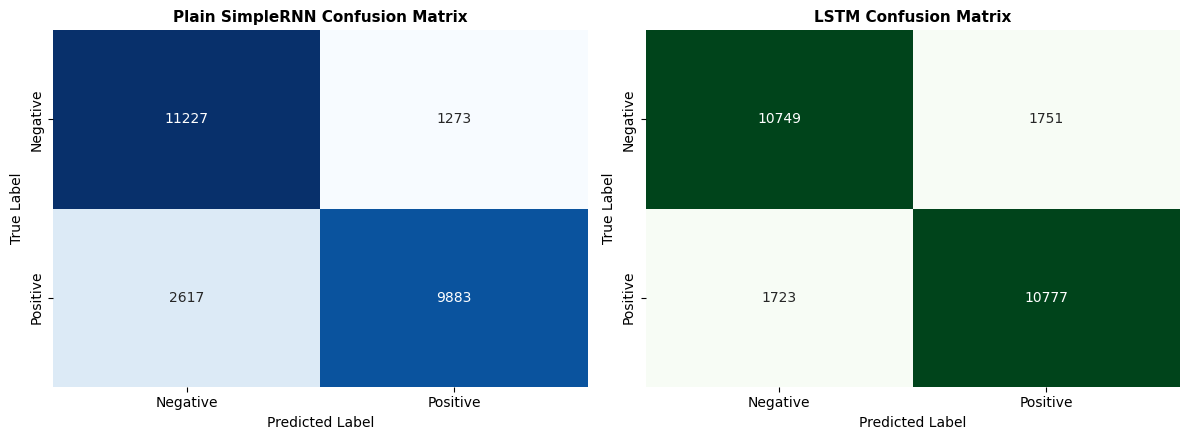

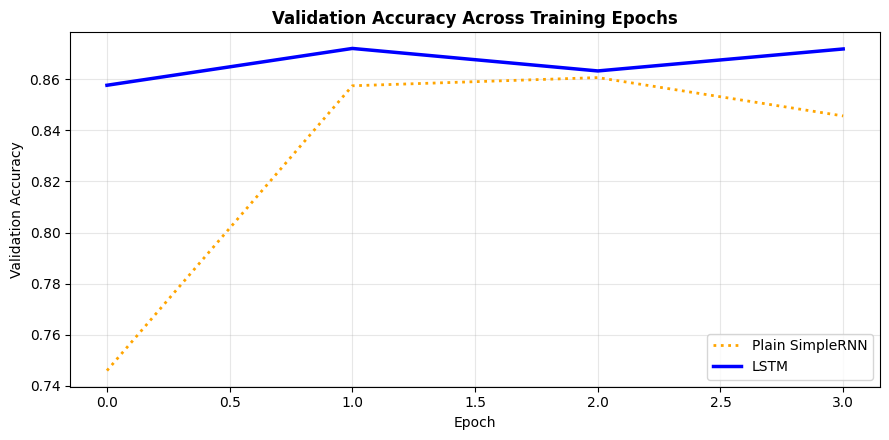

In [7]:
y_prob_rnn = model_rnn.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=0).flatten()
y_prob_lstm = model_lstm.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred_rnn = (y_prob_rnn >= 0.5).astype(int)
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

comparison_data = {
    "Architecture": [
        "Plain Recurrent Network (SimpleRNN)",
        "Long Short-Term Memory (LSTM)"
    ],
    "Order-Aware": ["Yes", "Yes"],
    "Gated Memory Cells": ["No", "Yes"],
    "Trainable Parameters": [
        model_rnn.count_params(),
        model_lstm.count_params()
    ],
    "Test Loss": [
        round(test_loss_rnn, 4),
        round(test_loss_lstm, 4)
    ],
    "Test Accuracy (%)": [
        round(accuracy_score(y_test, y_pred_rnn) * 100, 2),
        round(accuracy_score(y_test, y_pred_lstm) * 100, 2)
    ],
    "Precision (%)": [
        round(precision_score(y_test, y_pred_rnn) * 100, 2),
        round(precision_score(y_test, y_pred_lstm) * 100, 2)
    ],
    "Recall (%)": [
        round(recall_score(y_test, y_pred_rnn) * 100, 2),
        round(recall_score(y_test, y_pred_lstm) * 100, 2)
    ],
    "F1-Score (%)": [
        round(f1_score(y_test, y_pred_rnn) * 100, 2),
        round(f1_score(y_test, y_pred_lstm) * 100, 2)
    ],
    "ROC-AUC (%)": [
        round(roc_auc_score(y_test, y_prob_rnn) * 100, 2),
        round(roc_auc_score(y_test, y_prob_lstm) * 100, 2)
    ]
}
df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

cm_rnn = confusion_matrix(y_test, y_pred_rnn)
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(cm_rnn, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
axes[0].set_title("Plain SimpleRNN Confusion Matrix", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontsize=10)
axes[0].set_ylabel("True Label", fontsize=10)
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1],
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
axes[1].set_title("LSTM Confusion Matrix", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Predicted Label", fontsize=10)
axes[1].set_ylabel("True Label", fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.5))
plt.plot(history_rnn.history["val_accuracy"], label="Plain SimpleRNN", linestyle=":", color="orange", linewidth=2)
plt.plot(history_lstm.history["val_accuracy"], label="LSTM", linewidth=2.5, color="blue")
plt.title("Validation Accuracy Across Training Epochs", fontsize=12, fontweight="bold")
plt.xlabel("Epoch", fontsize=10)
plt.ylabel("Validation Accuracy", fontsize=10)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## <span style="color: #9f43c3ff">4. Theoretical Analysis: Why Gated Memory (LSTM) Outperforms Plain RNNs</span>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Theoretical Rationale:</b> Understanding the mathematical bottlenecks of sequential recurrent modeling and how gated architectures resolve information decay across long time horizons.

</blockquote>

### 4.1 The Vanishing Gradient Problem in Plain RNNs
In a standard recurrent neural network, hidden states are computed recursively:
$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

During backpropagation through time (BPTT), computing gradients with respect to early hidden states ($h_k$ where $k \ll t$) requires chained matrix products:
$$\frac{\partial h_t}{\partial h_k} = \prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}}$$

Because the derivative of $\tanh$ is bounded in $(0, 1]$ and recurrent weight matrix eigenvalues typically fall below 1, these gradients shrink exponentially over multiple time steps ($\frac{\partial h_t}{\partial h_k} \to 0$). Plain RNNs effectively forget early-sequence context over 300-word sequences.

### 4.2 Gated Memory Mechanics in LSTMs
The LSTM resolves exponential gradient decay by introducing an additive cell state ($C_t$) regulated by three learnable gates:
1. **Forget Gate ($f_t$):** Learns what proportion of historical cell state memory to discard:
   $$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$
2. **Input Gate ($i_t$) & Candidate State ($\tilde{C}_t$):** Determines what new information to write into memory:
   $$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
   $$\tilde{C}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$
3. **Additive Cell State Update ($C_t$):** Updates memory through linear addition rather than multiplicative matrix transformations:
   $$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
4. **Output Gate ($o_t$) & Hidden State ($h_t$):** Filters the updated cell memory to produce the emitted hidden state:
   $$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
   $$h_t = o_t \odot \tanh(C_t)$$

Because information flows through the cell state via addition, error gradients propagate backward across hundreds of time steps with minimal decay, enabling the LSTM to capture long-range contextual relationships and achieve superior classification accuracy.
